# Individual homework project 1

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
customers = pd.read_csv(r"E:\Data Internship\Datasets\customers.csv")
transactions = pd.read_csv(r"E:\Data Internship\Datasets\transaction.csv")
web_sessions = pd.read_csv(r"E:\Data Internship\Datasets\web_sessions.csv")
campaigns = pd.read_csv(r"E:\Data Internship\Datasets\marketing_campaigns.csv")

### Specific questions

Q1. What is the average purchase value for customers from Spain?

In [ ]:
country_name = 'Spain'
customers_spain = customers[customers['country'] == country_name]
avg_purchase = transactions[transactions['customer_id'].isin(customers_spain['customer_id'])]['purchase_value'].mean()
avg_purchase

75.63200247875355

Q2. What is the minimum purchase value for customers from Germany?

In [ ]:
country_name = 'Germany'
customers_germany = customers[customers['country'] == country_name]
min_purchase = transactions[transactions['customer_id'].isin(customers_germany['customer_id'])]['purchase_value'].min()
min_purchase

0.39

Q3. How much did males spend on buying products in the Sports category?

In [ ]:
merged_data = pd.merge(customers, transactions, on='customer_id')
sum_purchase = merged_data[(merged_data['gender'] == 'Male') &(merged_data['product_category'] == 'sports')]['purchase_value'].sum()
sum_purchase

191184.72

Q4. What is the average age of female customers from Canada?

In [ ]:
country_name = 'Canada'
gender = 'Female'
avg_age = customers[(customers['country'] == country_name) & (customers['gender'] == gender)]['age'].mean()
avg_age

42.9168765743073

Q5. How much does an average male customer from the UK spend?

In [ ]:
merged_data = pd.merge(customers, transactions, on='customer_id')
avg_purchase = merged_data[(merged_data['gender'] == 'Male') & (merged_data['country'] == 'UK')]['purchase_value'].mean()
avg_purchase

76.62530190677967

Q6. What is the maximum purchase value for females in the Toys category?

In [ ]:
merged_data = pd.merge(customers, transactions, on ='customer_id')
max_purchase = merged_data[(merged_data['gender'] == 'Female') & (merged_data['product_category'] == 'toys')]['purchase_value'].max()
max_purchase

423.84

Q7. What is the average number of pages viewed for customers who made a purchase (converted)?

In [ ]:
converted = 1
avg_pages_viewed = web_sessions[web_sessions['converted'] == converted]['pages_viewed'].mean()
avg_pages_viewed

5.728619675345898

Q8. What is the average time spent on the site for purchasing vs non-purchasing customers?

In [ ]:
converted = 0
converted = 1
avg_time_on_site = web_sessions.groupby('converted')['time_on_site'].mean()
avg_time_on_site

converted
0    299.238547
1    311.194837
Name: time_on_site, dtype: float64

### Visualisation tasks

Q9. Plot purchasing value across years.

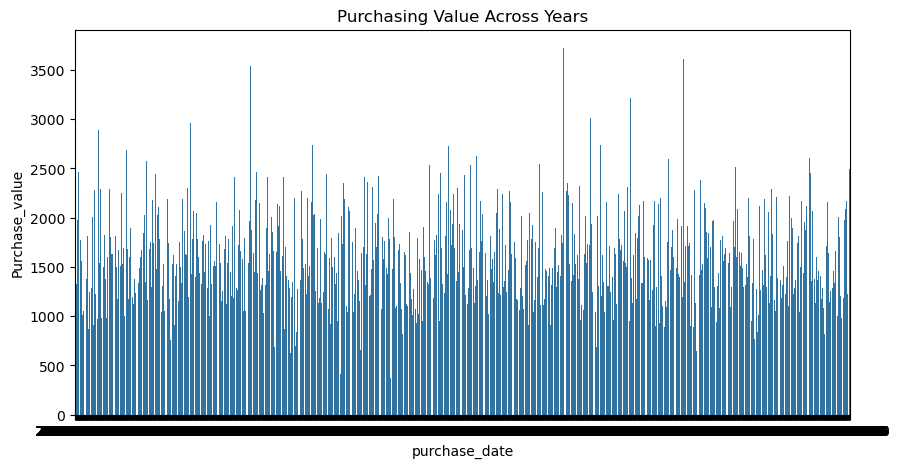

In [ ]:
yearly_sales = transactions.groupby('purchase_date')['purchase_value'].sum()
plt.figure(figsize=(10,5))
sns.barplot(x=yearly_sales.index, y=yearly_sales.values)
plt.title('Purchasing Value Across Years')
plt.xlabel('purchase_date')
plt.ylabel('Purchase_value')
plt.show()

Q10. Plot purchasing value across product categories.

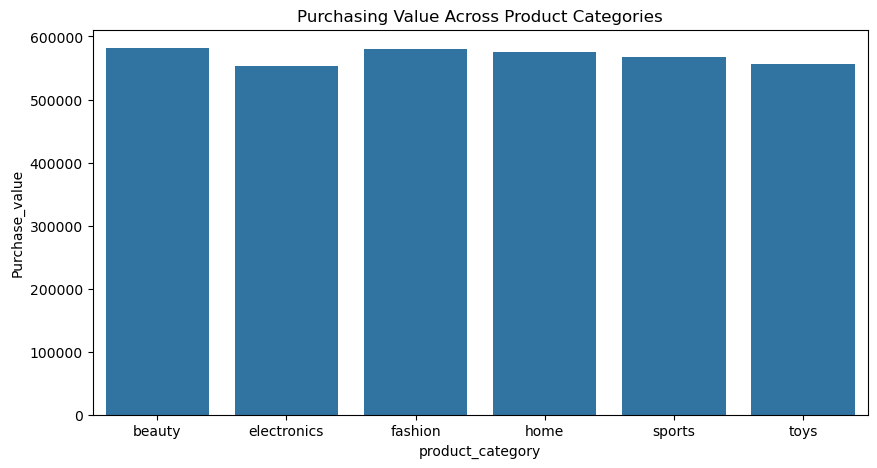

In [ ]:
product_category = transactions.groupby('product_category')['purchase_value'].sum()
plt.figure(figsize=(10,5))
sns.barplot(x=product_category.index, y=product_category.values)
plt.title('Purchasing Value Across Product Categories')
plt.xlabel('product_category')
plt.ylabel('Purchase_value')
plt.show()

### Free exercise

Explore the transactions dataset and:

- Create two visualisations of your choice
- Identify three patterns in the data
- Write five insights in plain English explaining what the data tells us

Your insights should focus on behaviour, spending patterns, or conversion

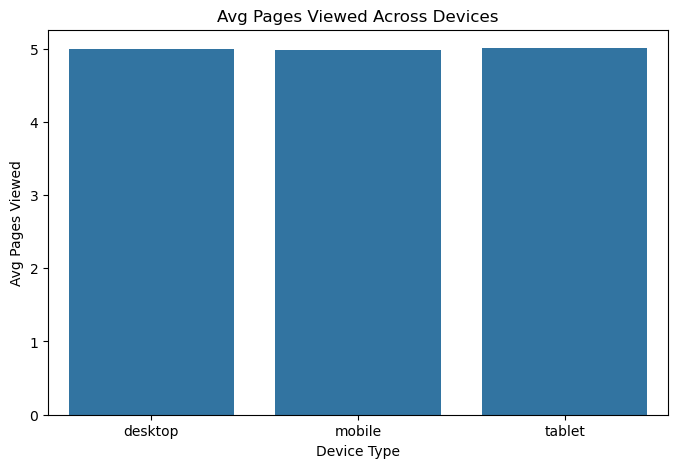

In [ ]:
devicetype = web_sessions.groupby('device_type')['pages_viewed'].mean()
plt.figure(figsize=(8,5))
sns.barplot(x=devicetype.index, y=devicetype.values)
plt.title('Avg Pages Viewed Across Devices')
plt.xlabel('Device Type')
plt.ylabel('Avg Pages Viewed')
plt.show()

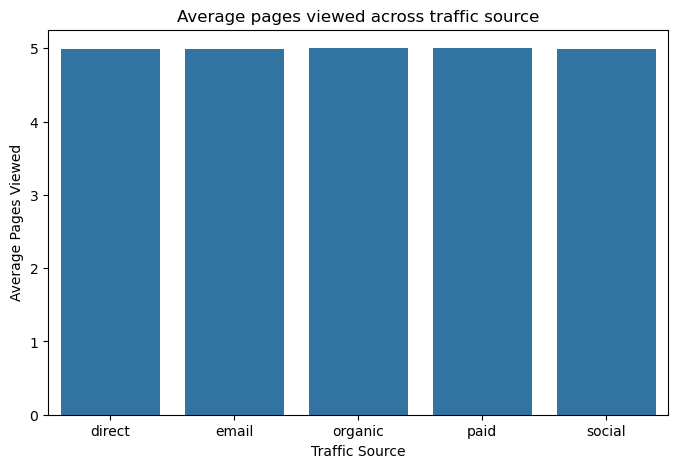

In [ ]:
trafficperpage = web_sessions.groupby('traffic_source')['pages_viewed'].mean()
plt.figure(figsize=(8,5))
sns.barplot(x=trafficperpage.index, y=trafficperpage.values)
plt.title('Average pages viewed across traffic source')
plt.xlabel('Traffic Source')
plt.ylabel('Average Pages Viewed')
plt.show()

Three Patterns in the Data:
1. Desktop users appear to view more pages on average compared to mobile users, suggesting higher browsing engagement.
2. Organic traffic sources lead to more pages viewed on average than paid sources, indicating that users coming from organic search may be more interested in exploring the site.
3. Traffic sources such as search engines or direct visits tend to generate higher page views than some social media sources.

Five Insights:
1. Desktop users may be more comfortable browsing multiple products, leading to higher engagement.
2. Higher page views may indicate stronger customer interest and a greater likelihood of conversion.
3. Users from direct or search traffic sources may already have clearer purchase intent when visiting the website.
4. Differences in browsing behaviour across devices suggest the website experience may vary between desktop and mobile users.
5. Lower-engagement traffic sources may require improved targeting or more relevant content to increase user interaction.